## 1. Setup & Data Loading
In this section, I load the cleaned dataset and explore its basic structure. 
I examine the number of records, key variables such as gender, and the overall loan approval rate. 
This helps verify that the dataset is ready for the fairness analysis.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from fairlearn.metrics import (
    demographic_parity_difference,
    demographic_parity_ratio,
    MetricFrame
)

import warnings
warnings.filterwarnings('ignore')

# Visualization defaults
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 120

FOUR_FIFTHS = 0.8  # Disparate Impact threshold

In [6]:
# Load cleaned dataset produced by Data Engineer
df = pd.read_csv("../data/df_clean.csv")

print(f"Dataset shape: {df.shape[0]} records x {df.shape[1]} columns")
print(f"\nGender distribution:\n{df['gender'].value_counts()}")
print(f"\nOverall approval rate: {df['loan_approved'].mean():.1%}")

Dataset shape: 480 records x 34 columns

Gender distribution:
gender
Male      242
Female    238
Name: count, dtype: int64

Overall approval rate: 58.8%


## 2. Gender Disparate Impact Analysis
In this section, I analyze loan approval rates by gender to detect potential bias. 
I compute the Disparate Impact (DI) ratio using the four-fifths rule to evaluate whether female applicants receive approvals at a significantly lower rate than male applicants.

In [7]:
# Filter to Male/Female only (1 record with "Unknown" gender excluded)
df_analysis = df[df['gender'].isin(['Male', 'Female'])].copy()
print(f"Records for gender analysis: {len(df_analysis)} (excluded {len(df) - len(df_analysis)} 'Unknown')")

# Compute approval rates by gender
gender_rates = df_analysis.groupby('gender')['loan_approved'].agg(['sum', 'count', 'mean'])
gender_rates.columns = ['Approved', 'Total', 'Approval Rate']
gender_rates['Rejected'] = gender_rates['Total'] - gender_rates['Approved']
gender_rates = gender_rates[['Total', 'Approved', 'Rejected', 'Approval Rate']]
print("\nApproval Rates by Gender")
print(gender_rates.to_string())

# Disparate Impact Ratio
rate_female = gender_rates.loc['Female', 'Approval Rate']
rate_male = gender_rates.loc['Male', 'Approval Rate']
di_gender = rate_female / rate_male

print(f"\n{'='*50}")
print(f"  Female approval rate:  {rate_female:.1%}")
print(f"  Male approval rate:    {rate_male:.1%}")
print(f"  Disparate Impact (DI): {di_gender:.4f}")
print(f"  Four-fifths threshold: {FOUR_FIFTHS}")
print(f"  DISPARATE IMPACT DETECTED: {di_gender < FOUR_FIFTHS}")
print(f"{'='*50}")

Records for gender analysis: 480 (excluded 0 'Unknown')

Approval Rates by Gender
        Total  Approved  Rejected  Approval Rate
gender                                          
Female    238       122       116       0.512605
Male      242       160        82       0.661157

  Female approval rate:  51.3%
  Male approval rate:    66.1%
  Disparate Impact (DI): 0.7753
  Four-fifths threshold: 0.8
  DISPARATE IMPACT DETECTED: True


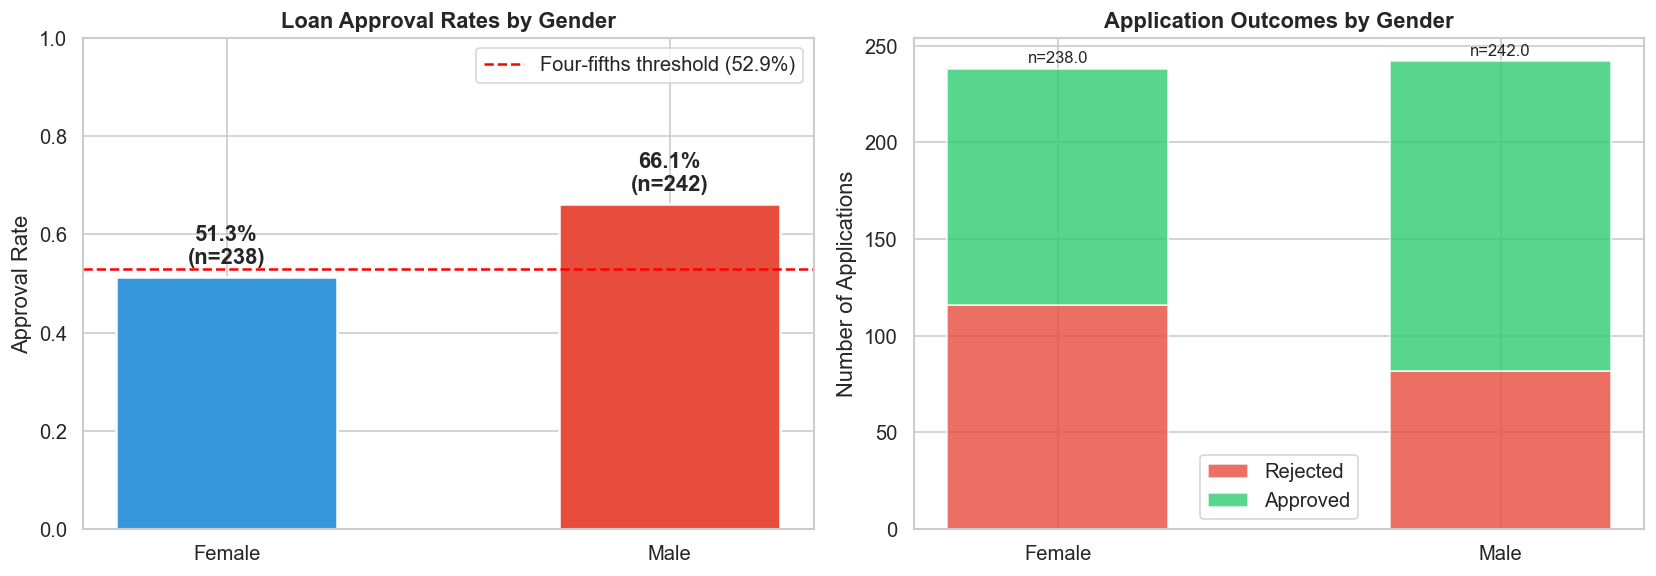

In [8]:
# Visualization: Approval rates by gender
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar(gender_rates.index, gender_rates['Approval Rate'],color=['#3498db', '#e74c3c'], edgecolor='white', linewidth=1.5, width=0.5)
axes[0].axhline(y=rate_male * FOUR_FIFTHS, color='red', linestyle='--', linewidth=1.5,
                label=f'Four-fifths threshold ({rate_male * FOUR_FIFTHS:.1%})')
axes[0].set_ylabel('Approval Rate')
axes[0].set_title('Loan Approval Rates by Gender', fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].legend(loc='upper right')

for bar, rate, n in zip(bars, gender_rates['Approval Rate'], gender_rates['Total']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{rate:.1%}\n(n={n})', ha='center', va='bottom', fontweight='bold')

# Stacked bar
axes[1].bar(gender_rates.index, gender_rates['Rejected'], label='Rejected',
            color='#e74c3c', alpha=0.8, width=0.5)
axes[1].bar(gender_rates.index, gender_rates['Approved'], bottom=gender_rates['Rejected'],
            label='Approved', color='#2ecc71', alpha=0.8, width=0.5)
axes[1].set_ylabel('Number of Applications')
axes[1].set_title('Application Outcomes by Gender', fontweight='bold')
axes[1].legend()

for i, (idx, row) in enumerate(gender_rates.iterrows()):
    axes[1].text(i, row['Total'] + 3, f"n={row['Total']}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()


In [9]:
# Statistical significance: Chi-square test of independence
contingency = pd.crosstab(df_analysis['gender'], df_analysis['loan_approved'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print(" Chi-Square Test: Gender x Loan Approval")
print(f"\nObserved counts:\n{contingency}")
print(f"\nExpected counts (under independence):")
print(pd.DataFrame(expected, index=contingency.index, columns=contingency.columns).round(1))
print(f"\nChi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom:   {dof}")
print(f"p-value:              {p_value:.6f}")
print(f"\nResult: The association between gender and approval is " f"{'statistically significant' if p_value < 0.05 else 'not significant'} (p = {p_value:.4f})")

 Chi-Square Test: Gender x Loan Approval

Observed counts:
loan_approved  False  True 
gender                     
Female           116    122
Male              82    160

Expected counts (under independence):
loan_approved  False  True 
gender                     
Female          98.2  139.8
Male            99.8  142.2

Chi-square statistic: 10.3220
Degrees of freedom:   1
p-value:              0.001315

Result: The association between gender and approval is statistically significant (p = 0.0013)


## 3. Fairlearn Metrics
Here I compute fairness metrics using the Fairlearn library. 
Metrics such as demographic parity difference and ratio help quantify disparities in approval outcomes between demographic groups.

In [10]:
y = df_analysis['loan_approved'].astype(int)
sensitive = df_analysis['gender']

dpd = demographic_parity_difference(y, y, sensitive_features=sensitive)
dpr = demographic_parity_ratio(y, y, sensitive_features=sensitive)

print("Fairlearn Demographic Parity Metrics")
print(f"  Demographic Parity Difference (DPD): {dpd:.4f}")
print(f"    Ideal = 0. Values > 0.05 suggest unfairness.")
print(f"  Demographic Parity Ratio (DPR):      {dpr:.4f}")
print(f"    Equivalent to DI ratio. Values < 0.8 indicate disparate impact.")

mf = MetricFrame(
    metrics={'approval_rate': lambda y_t, y_p: y_p.mean(),'count': lambda y_t, y_p: len(y_p)},
    y_true=y, y_pred=y,
    sensitive_features=sensitive
)
print(f"\n{mf.by_group}")


Fairlearn Demographic Parity Metrics
  Demographic Parity Difference (DPD): 0.1486
    Ideal = 0. Values > 0.05 suggest unfairness.
  Demographic Parity Ratio (DPR):      0.7753
    Equivalent to DI ratio. Values < 0.8 indicate disparate impact.

        approval_rate  count
gender                      
Female       0.512605  238.0
Male         0.661157  242.0


## 4. Rejection Reason Analysis
In this section, I analyze the reasons why loan applications were rejected and compare them across genders. 
By examining the distribution of rejection categories, I aim to identify whether certain reasons disproportionately affect male or female applicants. 
This helps assess whether the rejection process may contribute to potential gender disparities in loan approval outcomes.

In [11]:
rejected = df_analysis[df_analysis['loan_approved'] == False].copy()

rej_ct = pd.crosstab(rejected['gender'], rejected['rejection_reason'])
rej_pct = pd.crosstab(rejected['gender'], rejected['rejection_reason'], normalize='index')

print(" Rejection Reasons by Gender (Counts) ")
print(rej_ct)
print("\nRejection Reasons by Gender (Proportions) ")
print(rej_pct.round(3))

algo_f = rej_pct.loc['Female', 'algorithm_risk_score']
algo_m = rej_pct.loc['Male', 'algorithm_risk_score']
print(f"\nKey finding: {algo_f:.1%} of female rejections vs {algo_m:.1%} of male rejections")
print(f"are due to 'algorithm_risk_score'. This opaque category dominates rejections")
print(f"for BOTH genders, raising transparency concerns.")


 Rejection Reasons by Gender (Counts) 
rejection_reason  algorithm_risk_score  high_dti_ratio  \
gender                                                   
Female                              92               8   
Male                                67               4   

rejection_reason  insufficient_credit_history  low_income  
gender                                                     
Female                                     15           1  
Male                                        8           3  

Rejection Reasons by Gender (Proportions) 
rejection_reason  algorithm_risk_score  high_dti_ratio  \
gender                                                   
Female                           0.793           0.069   
Male                             0.817           0.049   

rejection_reason  insufficient_credit_history  low_income  
gender                                                     
Female                                  0.129       0.009  
Male                           

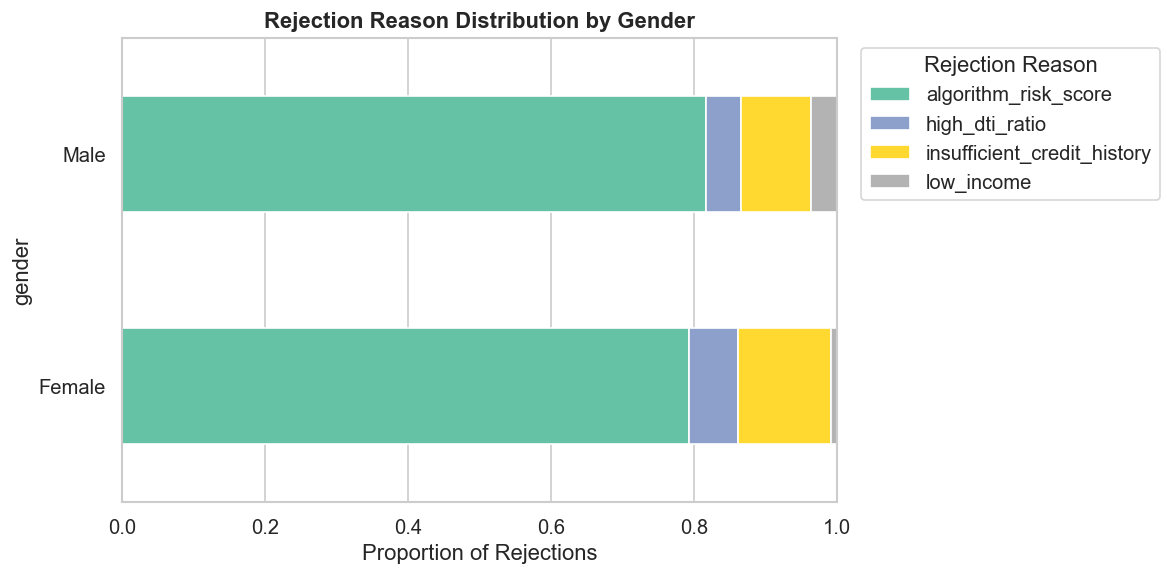

In [15]:
# Visualization: Rejection reasons
fig, ax = plt.subplots(figsize=(10, 5))
rej_pct.plot(kind='barh', stacked=True, ax=ax, colormap='Set2', edgecolor='white')
ax.set_xlabel('Proportion of Rejections')
ax.set_title('Rejection Reason Distribution by Gender', fontweight='bold')
ax.legend(title='Rejection Reason', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()


## 5. Age-Based Discrimination Analysis
In this section, I examine loan approval rates across different age groups to detect potential age-based disparities. 
Using Disparate Impact (DI), I compare each group’s approval rate with the best-performing group.

In [13]:
df_analysis['age_group'] = pd.cut(
    df_analysis['age'],
    bins=[20, 30, 40, 50, 60, 70],
    labels=['21-30', '31-40', '41-50', '51-60', '61-70']
)

age_rates = df_analysis.groupby('age_group')['loan_approved'].agg(['mean', 'count'])
age_rates.columns = ['Approval Rate', 'Count']

best_rate = age_rates['Approval Rate'].max()
best_group = age_rates['Approval Rate'].idxmax()
age_rates['DI vs Best'] = age_rates['Approval Rate'] / best_rate
age_rates['Disparate Impact'] = age_rates['DI vs Best'] < FOUR_FIFTHS

print(f"Age-Based Approval Rates (reference group: {best_group}, rate={best_rate:.1%})")
print(age_rates.to_string())

print(f"\nAge groups with DI < 0.8:")
for idx, row in age_rates[age_rates['Disparate Impact']].iterrows():
    print(f"   {idx}: approval rate = {row['Approval Rate']:.1%}, DI = {row['DI vs Best']:.3f}")

Age-Based Approval Rates (reference group: 41-50, rate=70.5%)
           Approval Rate  Count  DI vs Best  Disparate Impact
age_group                                                    
21-30           0.422222     90    0.598535              True
31-40           0.595376    173    0.843994             False
41-50           0.705426    129    1.000000             False
51-60           0.490196     51    0.694893              True
61-70           0.675676     37    0.957826             False

Age groups with DI < 0.8:
   21-30: approval rate = 42.2%, DI = 0.599
   51-60: approval rate = 49.0%, DI = 0.695


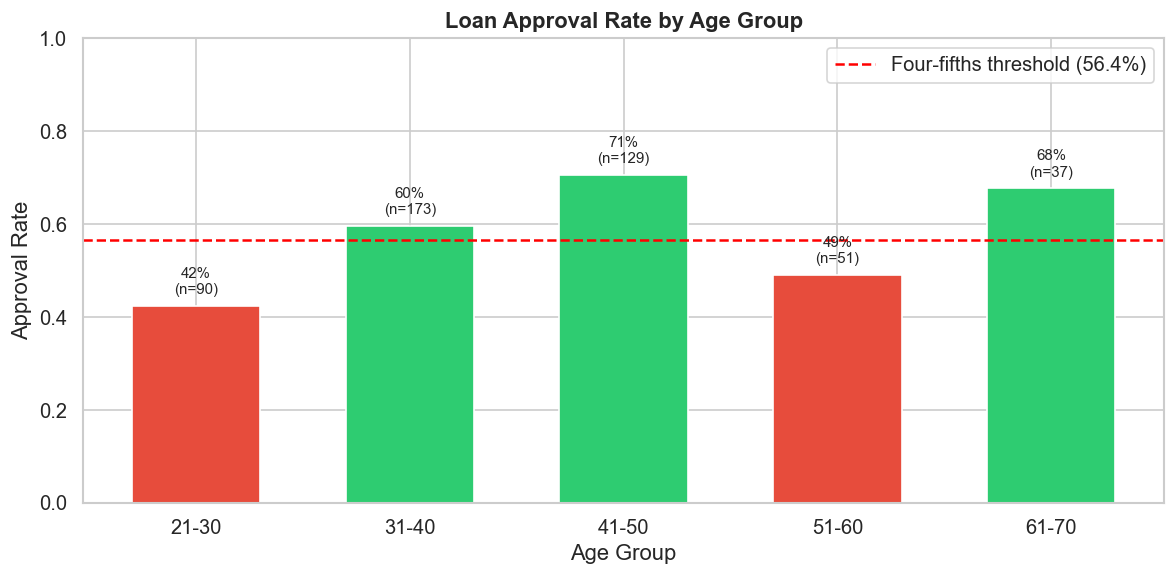

In [14]:
# Visualization: Age-based approval rates
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if di else '#2ecc71' for di in age_rates['Disparate Impact']]
bars = ax.bar(age_rates.index, age_rates['Approval Rate'], color=colors, edgecolor='white', width=0.6)
ax.axhline(y=best_rate * FOUR_FIFTHS, color='red', linestyle='--', linewidth=1.5,
           label=f'Four-fifths threshold ({best_rate * FOUR_FIFTHS:.1%})')
ax.set_ylabel('Approval Rate')
ax.set_xlabel('Age Group')
ax.set_title('Loan Approval Rate by Age Group', fontweight='bold')
ax.set_ylim(0, 1)
ax.legend()

for bar, rate, n in zip(bars, age_rates['Approval Rate'], age_rates['Count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{rate:.0%}\n(n={n})', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


## 6. Interaction Effects: Gender x Age
In this section, I analyze the interaction between gender and age to identify whether certain demographic combinations experience different loan approval outcomes. 
By comparing approval rates for each gender within each age group, I calculate the Disparate Impact (DI) to detect whether specific groups, such as younger or older women, face disproportionately lower approval rates.

In [16]:
# Gender x Age interaction
interaction = df_analysis.groupby(['age_group', 'gender'])['loan_approved'].agg(['mean', 'count']).reset_index()
interaction.columns = ['Age Group', 'Gender', 'Approval Rate', 'Count']

pivot = interaction.pivot(index='Age Group', columns='Gender', values='Approval Rate')
pivot_n = interaction.pivot(index='Age Group', columns='Gender', values='Count')
pivot['DI (F/M)'] = pivot['Female'] / pivot['Male']
pivot['Disparate Impact'] = pivot['DI (F/M)'] < FOUR_FIFTHS

print("Gender x Age Interaction: Approval Rates ")
print(pivot.round(3).to_string())
print(f"\nSample sizes:")
print(pivot_n.to_string())

Gender x Age Interaction: Approval Rates 
Gender     Female   Male  DI (F/M)  Disparate Impact
Age Group                                           
21-30       0.341  0.500     0.682              True
31-40       0.529  0.659     0.803             False
41-50       0.629  0.776     0.810             False
51-60       0.393  0.609     0.645              True
61-70       0.632  0.722     0.874             False

Sample sizes:
Gender     Female  Male
Age Group              
21-30          44    46
31-40          85    88
41-50          62    67
51-60          28    23
61-70          19    18


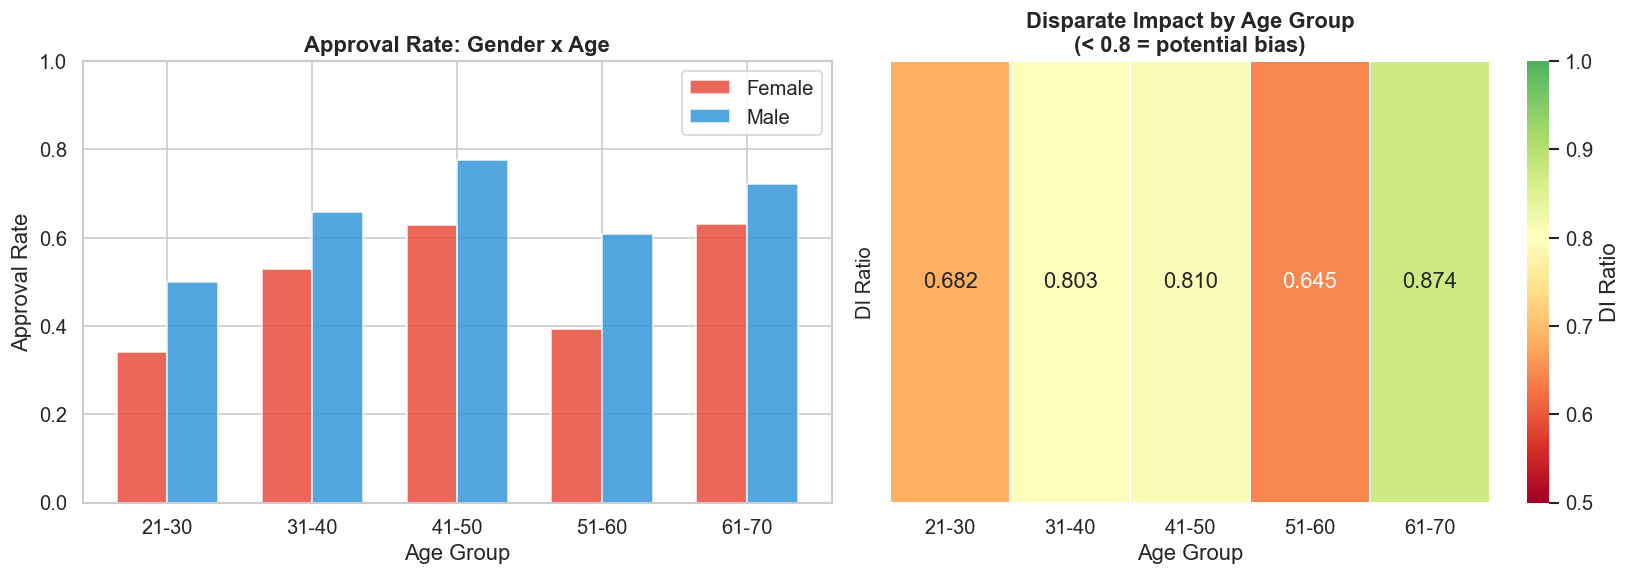


Key finding: The gender gap is WIDEST for the 21-30 group (DI = 0.682)
and 51-60 group (DI = 0.645).
Young women (21-30) have only a 34% approval rate vs 50% for young men.


In [17]:
# Visualization: Gender x Age interaction
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grouped bar chart
x = np.arange(len(pivot.index))
width = 0.35
axes[0].bar(x - width/2, pivot['Female'], width, label='Female', color='#e74c3c', alpha=0.85)
axes[0].bar(x + width/2, pivot['Male'], width, label='Male', color='#3498db', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(pivot.index)
axes[0].set_ylabel('Approval Rate')
axes[0].set_xlabel('Age Group')
axes[0].set_title('Approval Rate: Gender x Age', fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].legend()

# DI heatmap
di_data = pivot[['DI (F/M)']].copy()
di_data.columns = ['DI Ratio']
sns.heatmap(di_data.T, annot=True, fmt='.3f', cmap='RdYlGn', center=0.8,
            vmin=0.5, vmax=1.0, ax=axes[1], linewidths=1, cbar_kws={'label': 'DI Ratio'})
axes[1].set_title('Disparate Impact by Age Group\n(< 0.8 = potential bias)', fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print(f"\nKey finding: The gender gap is WIDEST for the 21-30 group (DI = {pivot.loc['21-30','DI (F/M)']:.3f})")
print(f"and 51-60 group (DI = {pivot.loc['51-60','DI (F/M)']:.3f}).")
print(f"Young women (21-30) have only a {pivot.loc['21-30','Female']:.0%} approval rate vs "
      f"{pivot.loc['21-30','Male']:.0%} for young men.")

## 7. Proxy Discrimination: Zip Code
In this section, I investigate whether zip codes may act as a proxy for demographic characteristics such as gender. 
By analyzing gender concentration and approval rates across zip code prefixes, I assess whether geographic variables may indirectly introduce bias into the loan approval process.

In [18]:
# Zip code prefix analysis
df_analysis['zip_prefix'] = df_analysis['zip_code'].astype(str).str[:3]

zip_stats = df_analysis.groupby('zip_prefix').agg(
    total=('loan_approved', 'count'),
    pct_female=('gender', lambda x: (x == 'Female').mean()),
    approval_rate=('loan_approved', 'mean')
).sort_values('total', ascending=False)

print(" Zip Code Prefix: Gender Concentration & Approval Rates ")
print(zip_stats.round(3).to_string())

# Correlation: zip_is_902 vs is_female
zip_902 = (df_analysis['zip_prefix'] == '902').astype(int)
is_female = (df_analysis['gender'] == 'Female').astype(int)
r_proxy, p_proxy = stats.pointbiserialr(zip_902, is_female)

print(f"\nCRITICAL PROXY FINDING:")
print(f"  Zip 100xx: {zip_stats.loc['100','pct_female']:.0%} Female, "
      f"{zip_stats.loc['100','approval_rate']:.1%} approval rate, n={zip_stats.loc['100','total']}")
print(f"  Zip 902xx: {zip_stats.loc['902','pct_female']:.0%} Female, "
      f"{zip_stats.loc['902','approval_rate']:.1%} approval rate, n={zip_stats.loc['902','total']}")
print(f"\n  Zip code correlation with gender: r = {r_proxy:.3f} (p < 0.001)")
print(f"  Using zip code in credit models effectively reintroduces gender as a feature.")

 Zip Code Prefix: Gender Concentration & Approval Rates 
            total  pct_female  approval_rate
zip_prefix                                  
100           245       0.114          0.645
902           217       0.931          0.525
300            18       0.444          0.556

CRITICAL PROXY FINDING:
  Zip 100xx: 11% Female, 64.5% approval rate, n=245
  Zip 902xx: 93% Female, 52.5% approval rate, n=217

  Zip code correlation with gender: r = 0.790 (p < 0.001)
  Using zip code in credit models effectively reintroduces gender as a feature.


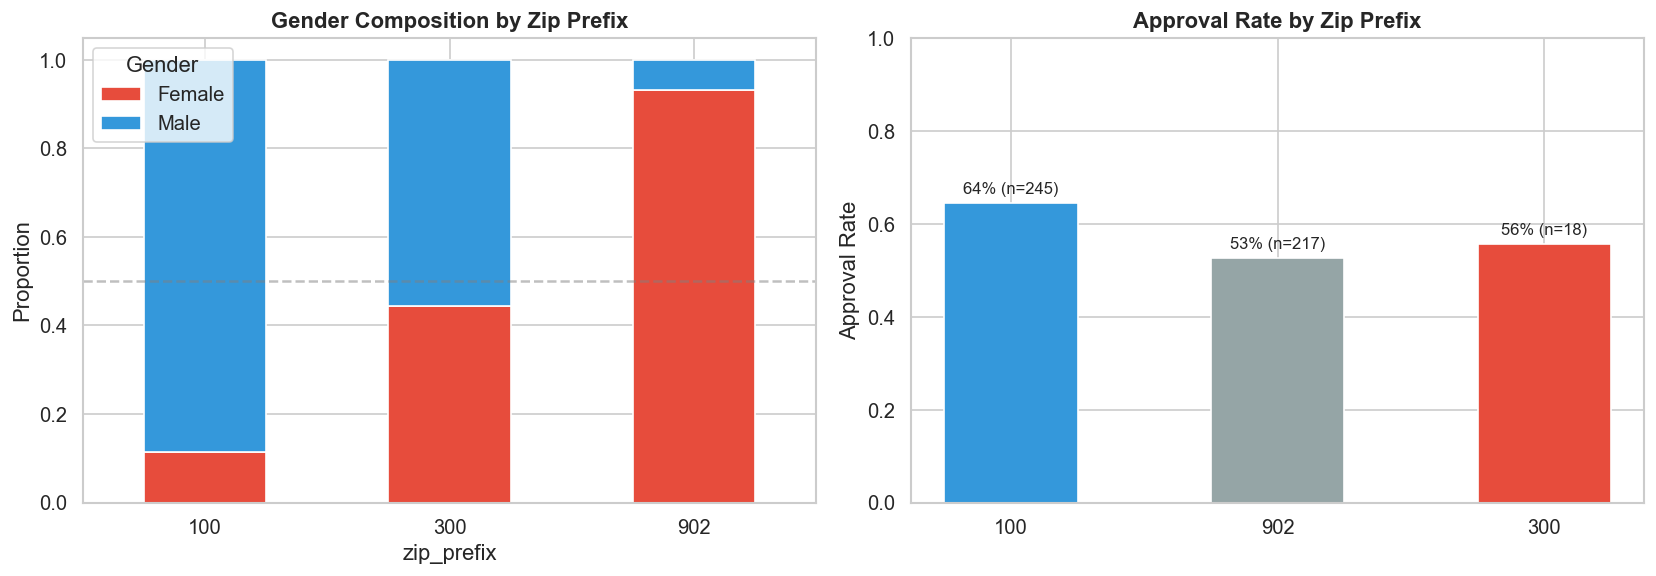

In [19]:
# Visualization: Zip code as proxy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender composition
zip_gender = df_analysis.groupby(['zip_prefix', 'gender']).size().unstack(fill_value=0)
zip_gender_pct = zip_gender.div(zip_gender.sum(axis=1), axis=0)
zip_gender_pct.plot(kind='bar', stacked=True, ax=axes[0], color=['#e74c3c', '#3498db'], edgecolor='white')
axes[0].set_ylabel('Proportion')
axes[0].set_title('Gender Composition by Zip Prefix', fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Gender')
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

# Approval rates by zip
bars = axes[1].bar(zip_stats.index, zip_stats['approval_rate'],
                   color=['#3498db', '#95a5a6', '#e74c3c'], edgecolor='white', width=0.5)
axes[1].set_ylabel('Approval Rate')
axes[1].set_title('Approval Rate by Zip Prefix', fontweight='bold')
axes[1].set_ylim(0, 1)
for bar, rate, n in zip(bars, zip_stats['approval_rate'], zip_stats['total']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{rate:.0%} (n={n})', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [20]:
# DI within each zip code: does gender bias persist after controlling for location?
print("Disparate Impact WITHIN Zip Code Prefixes\n")
for z in ['100', '902']:
    subset = df_analysis[df_analysis['zip_prefix'] == z]
    rates = subset.groupby('gender')['loan_approved'].mean()
    counts = subset.groupby('gender').size()
    if 'Female' in rates and 'Male' in rates and rates['Male'] > 0:
        di = rates['Female'] / rates['Male']
        print(f"Zip {z}xx:")
        print(f"  Female: {rates['Female']:.1%} (n={counts['Female']})")
        print(f"  Male:   {rates['Male']:.1%} (n={counts['Male']})")
        di_label = "DISPARATE IMPACT" if di < 0.8 else "Above threshold"
        print(f"  DI = {di:.4f} ({di_label})")
        print()

print("Note: Within zip 100xx, the DI is even LOWER than the overall DI,")
print("suggesting that zip code does not explain away the gender gap.")

Disparate Impact WITHIN Zip Code Prefixes

Zip 100xx:
  Female: 46.4% (n=28)
  Male:   66.8% (n=217)
  DI = 0.6948 (DISPARATE IMPACT)

Zip 902xx:
  Female: 52.0% (n=202)
  Male:   60.0% (n=15)
  DI = 0.8663 (Above threshold)

Note: Within zip 100xx, the DI is even LOWER than the overall DI,
suggesting that zip code does not explain away the gender gap.


## 8. Spending Behavior as Proxy

In this section, I investigate whether spending behavior features correlate with gender and loan approval. 
This helps identify whether certain spending categories may act as proxy variables that indirectly introduce gender bias.

In [21]:
# Spending category correlations with gender and approval
spend_cols = [c for c in df.columns if c.startswith('spend_')]
df_analysis['is_female'] = (df_analysis['gender'] == 'Female').astype(int)
df_analysis['approved_int'] = df_analysis['loan_approved'].astype(int)

proxy_results = []
for col in spend_cols:
    corr_gender, p_gender = stats.pointbiserialr(df_analysis['is_female'], df_analysis[col])
    corr_approval, p_approval = stats.pointbiserialr(df_analysis[col], df_analysis['approved_int'])
    proxy_results.append({
        'Category': col.replace('spend_', ''),
        'Corr with Gender': round(corr_gender, 3),
        'p (Gender)': round(p_gender, 4),
        'Corr with Approval': round(corr_approval, 3),
        'p (Approval)': round(p_approval, 4),
        'Potential Proxy': abs(corr_gender) > 0.08 and p_gender < 0.1
    })

proxy_df = pd.DataFrame(proxy_results).sort_values('Corr with Gender', key=abs, ascending=False)
print("Spending Category Correlation Analysis ")
print(proxy_df.to_string(index=False))

flagged = proxy_df[proxy_df['Potential Proxy']]
print(f"\n{len(flagged)} spending categories show significant correlation with gender:")
for _, row in flagged.iterrows():
    direction = "Female-associated" if row['Corr with Gender'] > 0 else "Male-associated"
    print(f"   - {row['Category']} (r = {row['Corr with Gender']:.3f}, {direction})")


Spending Category Correlation Analysis 
           Category  Corr with Gender  p (Gender)  Corr with Approval  p (Approval)  Potential Proxy
           gambling             0.101      0.0266              -0.019        0.6839             True
           shopping            -0.085      0.0621               0.077        0.0913             True
adult entertainment            -0.076      0.0966               0.003        0.9420            False
          education             0.058      0.2050              -0.026        0.5651            False
          insurance            -0.048      0.2981               0.065        0.1582            False
          groceries            -0.047      0.3004               0.023        0.6114            False
            fitness            -0.042      0.3607              -0.036        0.4313            False
      entertainment             0.041      0.3710              -0.038        0.4066            False
            alcohol            -0.036      0.4365  

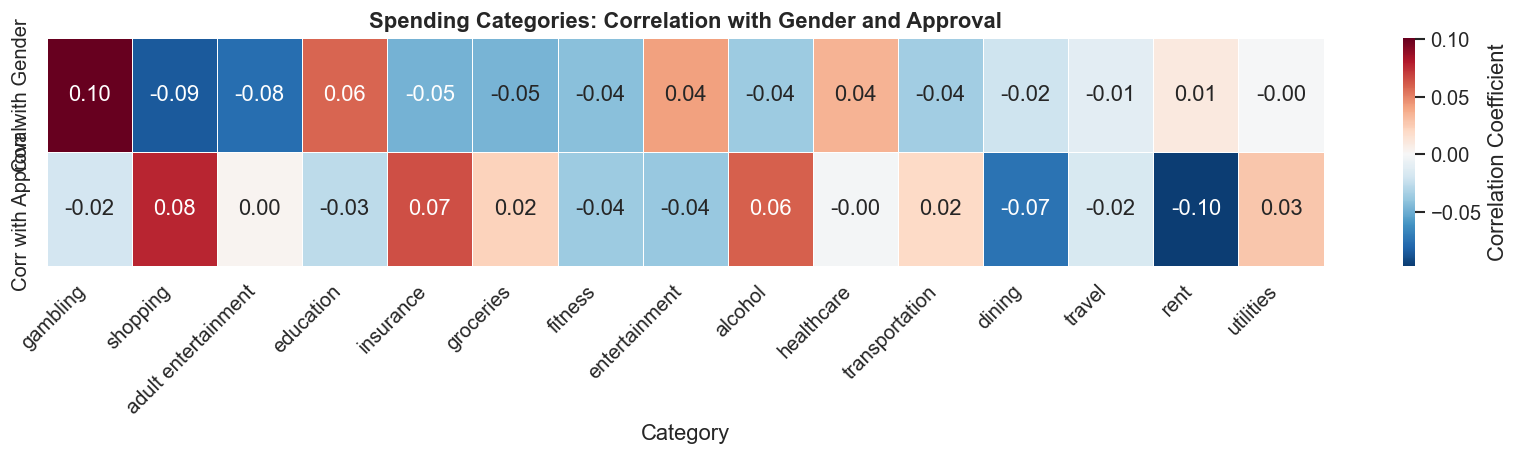

In [22]:
# Visualization: Spending proxy heatmap
fig, ax = plt.subplots(figsize=(14, 4))

corr_data = proxy_df.set_index('Category')[['Corr with Gender', 'Corr with Approval']].T
sns.heatmap(corr_data, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, linewidths=0.5, cbar_kws={'label': 'Correlation Coefficient'})
ax.set_title('Spending Categories: Correlation with Gender and Approval', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 9. Controlling for Financial Variables
In this section, I compare financial characteristics between male and female applicants to determine whether differences in income, credit history, or debt explain the observed approval gap.

In [23]:
# Financial feature comparison
financial_cols = ['annual_income', 'credit_history_months', 'debt_to_income', 'savings_balance']

print(" Financial Features by Gender (Mean +/- Std) \n")
comparison = []
for col in financial_cols:
    f_vals = df_analysis[df_analysis['gender']=='Female'][col]
    m_vals = df_analysis[df_analysis['gender']=='Male'][col]
    t_stat, p_val = stats.ttest_ind(f_vals, m_vals)
    comparison.append({
        'Feature': col,
        'Female Mean': f'{f_vals.mean():.1f}',
        'Male Mean': f'{m_vals.mean():.1f}',
        'Difference': f'{f_vals.mean() - m_vals.mean():.1f}',
        't-stat': f'{t_stat:.3f}',
        'p-value': f'{p_val:.4f}',
        'Significant': p_val < 0.05
    })

print(pd.DataFrame(comparison).to_string(index=False))
print("\nNo statistically significant differences in financial features between genders.")
print("The approval gap cannot be explained by differences in income, credit history, DTI, or savings.")

 Financial Features by Gender (Mean +/- Std) 

              Feature Female Mean Male Mean Difference t-stat p-value  Significant
        annual_income     84657.3   81066.1     3591.2  1.413  0.1584        False
credit_history_months        51.6      49.9        1.7  0.597  0.5509        False
       debt_to_income         0.2       0.2       -0.0 -1.191  0.2343        False
      savings_balance     29747.9   29362.1      385.8  0.256  0.7984        False

No statistically significant differences in financial features between genders.
The approval gap cannot be explained by differences in income, credit history, DTI, or savings.


In [24]:
# Logistic regression: Does gender remain significant after controlling for financials?
features = ['annual_income', 'credit_history_months', 'debt_to_income', 'savings_balance', 'age']
X = df_analysis[features + ['is_female']].dropna()
y_lr = df_analysis.loc[X.index, 'loan_approved'].astype(int)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_scaled, y_lr)

print("Logistic Regression: Approval ~ Financials + Gender\n")
coef_df = pd.DataFrame({
    'Feature': features + ['is_female'],
    'Coefficient': lr.coef_[0].round(4),
    'Odds Ratio': np.exp(lr.coef_[0]).round(3)
}).sort_values('Coefficient', key=abs, ascending=False)

print(coef_df.to_string(index=False))
print(f"\nModel accuracy: {lr.score(X_scaled, y_lr):.1%}")

is_female_coef = lr.coef_[0][-1]
print(f"\nCRITICAL FINDING: 'is_female' has the LARGEST magnitude coefficient ({is_female_coef:.4f}),")
print(f"even after controlling for all financial variables.")
print(f"Odds ratio = {np.exp(is_female_coef):.3f} -> women are ~{(1 - np.exp(is_female_coef))*100:.0f}% less likely")
print(f"to be approved, all else being equal.")


Logistic Regression: Approval ~ Financials + Gender

              Feature  Coefficient  Odds Ratio
            is_female      -0.3462       0.707
        annual_income       0.2861       1.331
credit_history_months       0.2839       1.328
      savings_balance       0.1067       1.113
                  age      -0.0658       0.936
       debt_to_income       0.0461       1.047

Model accuracy: 64.6%

CRITICAL FINDING: 'is_female' has the LARGEST magnitude coefficient (-0.3462),
even after controlling for all financial variables.
Odds ratio = 0.707 -> women are ~29% less likely
to be approved, all else being equal.


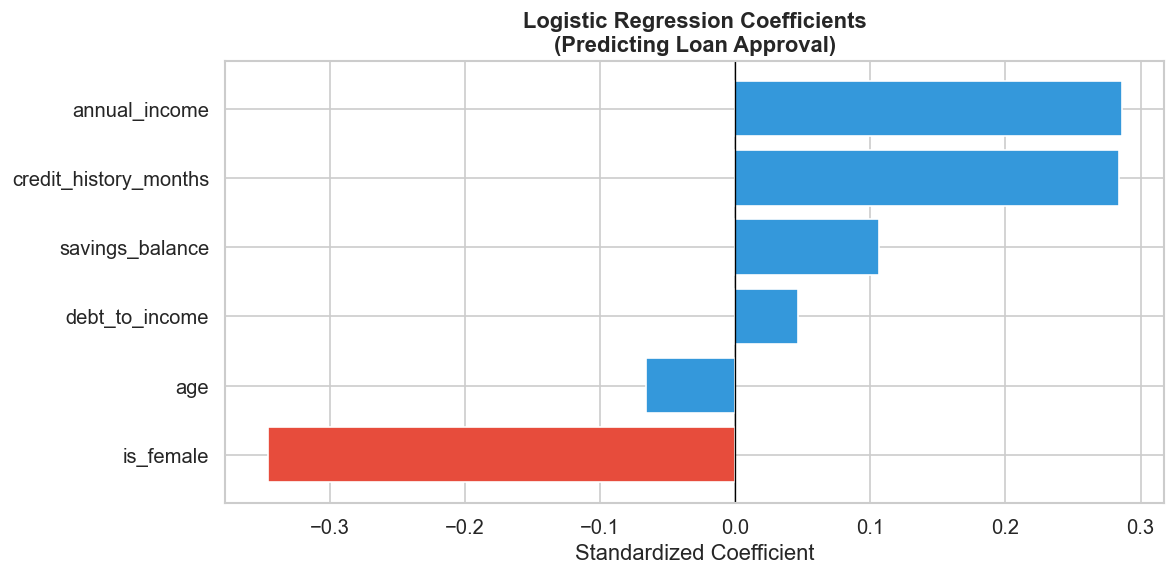

In [25]:
# Visualization: Logistic regression coefficients
fig, ax = plt.subplots(figsize=(10, 5))
coef_sorted = coef_df.sort_values('Coefficient')
colors = ['#e74c3c' if f == 'is_female' else '#3498db' for f in coef_sorted['Feature']]
ax.barh(coef_sorted['Feature'], coef_sorted['Coefficient'], color=colors, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Standardized Coefficient')
ax.set_title('Logistic Regression Coefficients\n(Predicting Loan Approval)', fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Interest Rate & Approved Amount Analysis
In this section, I examine whether approved male and female applicants receive different loan terms by comparing interest rates and approved loan amounts.

In [26]:
approved = df_analysis[df_analysis['loan_approved'] == True]

# Interest rates
print("Interest Rates by Gender (Approved Loans Only)")
print(approved.groupby('gender')['interest_rate'].describe().round(2))

t_ir, p_ir = stats.ttest_ind(
    approved[approved.gender=='Female']['interest_rate'].dropna(),
    approved[approved.gender=='Male']['interest_rate'].dropna()
)
print(f"\nt-test for interest rate: t = {t_ir:.4f}, p = {p_ir:.4f}")
print(f"-> {'Significant' if p_ir < 0.05 else 'Not significant'} difference in interest rates")

# Approved amounts
print("\nApproved Amounts by Gender")
print(approved.groupby('gender')['approved_amount'].describe().round(0))

t_amt, p_amt = stats.ttest_ind(
    approved[approved.gender=='Female']['approved_amount'].dropna(),
    approved[approved.gender=='Male']['approved_amount'].dropna()
)
print(f"\nt-test for approved amount: t = {t_amt:.4f}, p = {p_amt:.4f}")
print(f"-> {'Significant' if p_amt < 0.05 else 'Not significant'} difference in amounts")
print("\nNote: While term differences are not statistically significant,")
print("the primary discrimination occurs at the APPROVAL GATE, not in terms offered.")

Interest Rates by Gender (Approved Loans Only)
        count  mean   std  min   25%  50%   75%  max
gender                                              
Female  122.0  4.50  1.20  2.5  3.40  4.5  5.57  6.5
Male    160.0  4.62  1.14  2.6  3.68  4.7  5.60  6.5

t-test for interest rate: t = -0.8515, p = 0.3952
-> Not significant difference in interest rates

Approved Amounts by Gender
        count     mean      std      min      25%      50%      75%      max
gender                                                                      
Female  122.0  46533.0  18074.0  15000.0  32250.0  47500.0  59750.0  79000.0
Male    160.0  48844.0  18212.0  15000.0  35000.0  49000.0  64250.0  80000.0

t-test for approved amount: t = -1.0592, p = 0.2904
-> Not significant difference in amounts

Note: While term differences are not statistically significant,
the primary discrimination occurs at the APPROVAL GATE, not in terms offered.


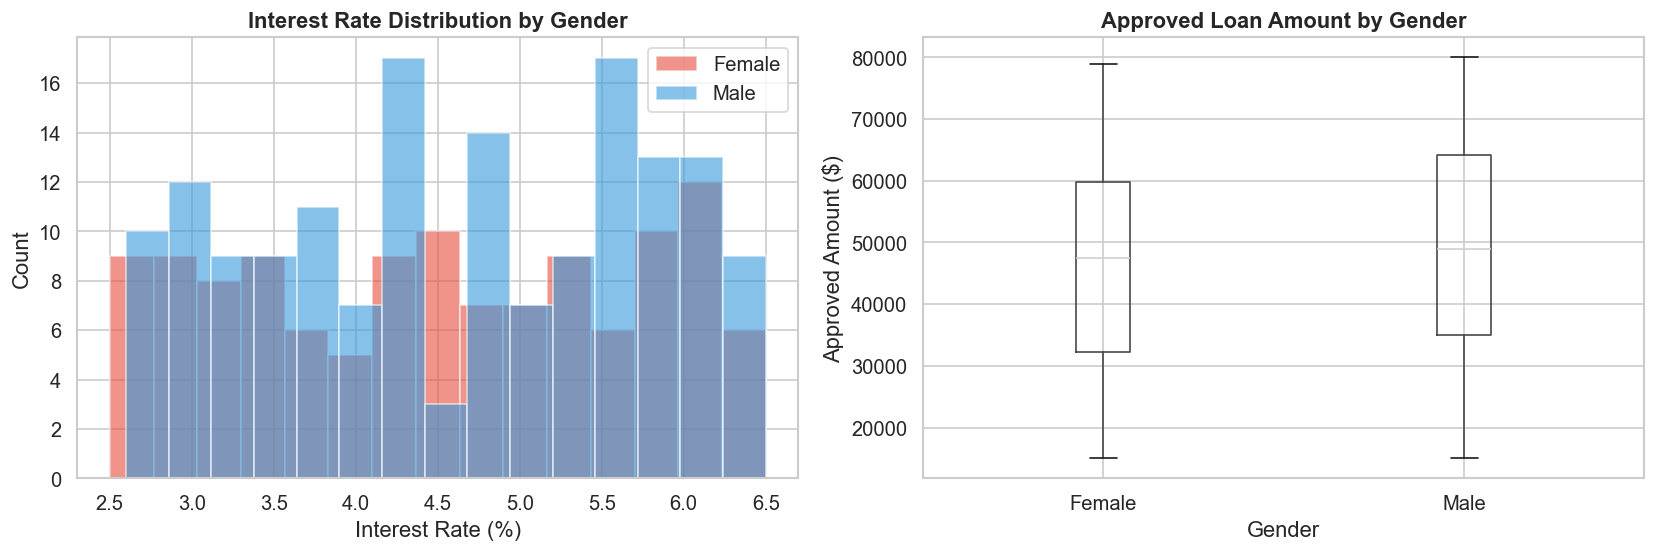

In [27]:
# Visualization: Interest rate and amounts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for gender, color in [('Female', '#e74c3c'), ('Male', '#3498db')]:
    subset = approved[approved['gender'] == gender]
    axes[0].hist(subset['interest_rate'].dropna(), bins=15, alpha=0.6, label=gender,
                 color=color, edgecolor='white')
axes[0].set_xlabel('Interest Rate (%)')
axes[0].set_ylabel('Count')
axes[0].set_title('Interest Rate Distribution by Gender', fontweight='bold')
axes[0].legend()

approved.boxplot(column='approved_amount', by='gender', ax=axes[1])
axes[1].set_title('Approved Loan Amount by Gender', fontweight='bold')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Approved Amount ($)')
plt.suptitle('')
plt.tight_layout()
plt.show()
